In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pypalettes import load_cmap

# Import Data

In [4]:
df = pd.read_csv("../data/natural_disasters.csv", parse_dates=["start_datetime", "end_datetime"])

df = (

    # group by year and region, count the number of disasters in each group
    df.groupby(["start_year", "region"])
    .size()
    .reset_index(name="count")      # DataFrame: start_year | region | count

    # tranpose each region (continent) into a column
    .pivot(
        index="start_year", 
        columns="region", 
        values="count"
    )

    # add a column for the total number of disasters each year
    .assign(total=lambda x: x.sum(axis=1))

    # format as a clean DataFrame
    .rename_axis(columns=None)      # remove name of the columns index
    .reset_index()

    # filter year range
    .loc[
        lambda x: (x["start_year"] >= 1960) & (x["start_year"] <= 2024)
    ]
)

df

,start_year,Africa,Americas,Asia,Europe,Oceania,total
60,1960,3.0,11.0,22.0,1.0,2.0,39.0
61,1961,2.0,8.0,17.0,3.0,1.0,31.0
62,1962,1.0,12.0,13.0,4.0,1.0,31.0
63,1963,4.0,17.0,20.0,3.0,NaN,44.0
64,1964,8.0,18.0,33.0,2.0,2.0,63.0
...,...,...,...,...,...,...,...
120,2020,93.0,92.0,162.0,49.0,18.0,414.0
121,2021,64.0,129.0,175.0,53.0,16.0,437.0
122,2022,93.0,120.0,141.0,71.0,10.0,435.0
123,2023,78.0,99.0,171.0,95.0,17.0,460.0


# Global Natural Disasters Over Time

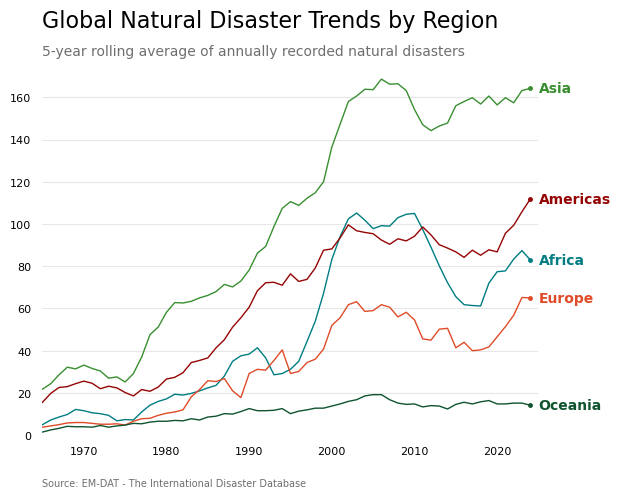

In [5]:
WINDOW = 5     # window size to calculate average (for line smoothing)

# choose a colour palette
cmap = load_cmap("Abbott")
order = [6, 0, 4, 1, 5]         # explicit colour palette ordering (for looping)
colours = [cmap.colors[idx] for idx in order]

# create figure
fig, ax = plt.subplots()

# axes customisation
ax.grid(True, alpha=0.3, axis="y")                                  # create horizontal grid lines only
ax.spines[["top", "right", "bottom", "left"]].set_visible(False)    # remove all spines
ax.tick_params(length=0, pad=8, labelsize=8)        # control tick label distance to axis and remove markers

# set axes limits
ax.set_xlim(df["start_year"].min() + WINDOW, df["start_year"].max() + 1)
ax.set_ylim(0, 175)

# multi-line time series plot
for i, region in enumerate(df.columns[1:-1]):

    # use a rolling window to average (smoothen) fluctuations over time
    rolling_counts = df[region].rolling(window=WINDOW, min_periods=min(WINDOW, 3), center=False).mean()     

    # plot line for each region
    ax.plot(
        df["start_year"], rolling_counts, 
        label=region,
        linewidth=1,
        color=colours[i]
    )

    # last data point marker
    ax.scatter(
        df["start_year"].iloc[-1],
        rolling_counts.iloc[-1],
        marker=".",
        s=25,
        color=colours[i]
    )

    # text annotation to highlight region
    ax.text(
        x=df["start_year"].iloc[-1] + 1,
        y=rolling_counts.iloc[-1],
        s=region,
        ha="left",
        va="center",
        color=colours[i],
        fontsize=10,
        weight="bold"
    )

# chart title
x_value, y_value = 0.124, .96
fig.text(
    x=x_value, y=y_value,
    s=f"Global Natural Disaster Trends by Region",    
    size=16
)

# chart subtitle
fig.text(
    x=x_value, y=y_value * 0.94,
    s=f"{WINDOW}-year rolling average of annually recorded natural disasters",
    size=10,
    color="#6e6e6e"
)

# chart caption
fig.text(
    x_value, 0,
    "Source: EM-DAT - The International Disaster Database",
    ha="left",
    va="bottom",
    fontsize=7,
    color="#6e6e6e",
)

plt.savefig("../images/disasters_over_time.svg", bbox_inches="tight")

plt.show()